In [4]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# 1. Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
  
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [6]:
df = pd.read_csv(r"C:\Users\kisho\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.columns = df.columns.str.strip()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


In [14]:
def plot_histogram(df, column_name):
    plt.figure(figsize=(5,3))
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()
    plt.axvline(col_mean, color='red', linestyle='--', label=f'Mean: {col_mean:.2f}')
    plt.axvline(col_median, color='green', linestyle='-', label=f'Median: {col_median:.2f}')
    plt.legend()
    plt.show()


In [54]:
import pandas as pd


In [8]:
!pip install pandas


In [ ]:
!pip install pandas

In [5]:
df=pd.read_csv(r"C:\Users\kisho\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [8]:
df.shape


(7043, 21)

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
pd.set_option("display.max_columns",None)

In [10]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [58]:
df = df.drop(columns=["customerID"])

In [70]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [9]:
#printing the unique values in all the columns
for col in df.columns:
    print(col,df[col].unique())
    print('-'*50)

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSec

In [72]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [30]:
df["TotalCharges "] = df["TotalCharges"].astype(float)

In [73]:
df[df["TotalCharges"]==" "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [17]:
len(df[df["TotalCharges"]==' '])

11

In [21]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0.0")

In [22]:
df["TotalCharges "] = df["TotalCharges"].astype(float)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [32]:
#checking the class distribution of target column
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


Insights:
1.Customer ID removed as it is not required for modeling
2.No missing value in the dataset
3.Missing value in the Totalcharges column were replaced with 0
4.class imbalance identified in the target

Exploratory Data Analysis(EDA)

In [33]:
df.shape

(7043, 22)

In [75]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [76]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [49]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2285.169963
std,0.368612,24.559481,30.090047,2267.544511
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.675000
50%,0.000000,29.000000,70.350000,1398.250000
75%,0.000000,55.000000,89.850000,3803.050000
max,1.000000,72.000000,118.750000,8684.800000


Numerical Features - Analysis

Understanding the distribution of Tech numerical features

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_histogram(df,column_name):
    

    plt.figure(figsize=(5,3))
    
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")

    #calculate the mean and median values for the columns
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()

    #add vertical lines for mean and median
    plt.axvline(col_mean,color="red" , linestyle="--",label="Mean")
    plt.axvline(col_median,color="green" , linestyle="-", label="Median")

    plt.legend()

    plt.show()
                    

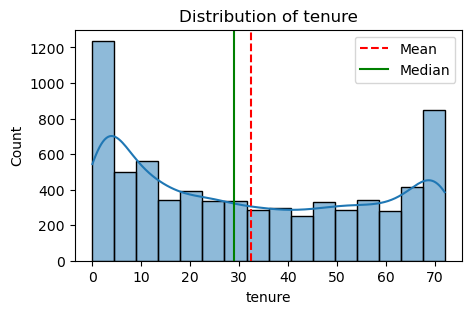

In [15]:
plot_histogram(df, "tenure")

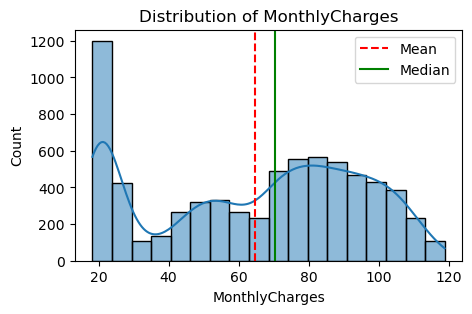

In [46]:
plot_histogram(df, "MonthlyCharges")

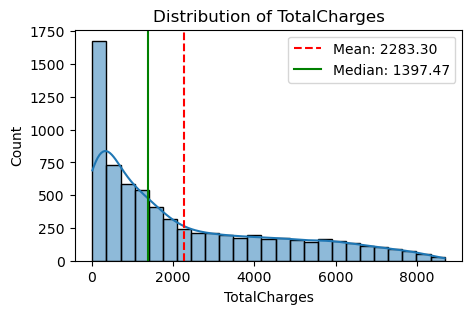

In [44]:
plot_histogram(df, "TotalCharges")

 box plot for numerical features

In [53]:
def plot_boxplot(df, column_name):

    plt.figure(figsize=(5,3))
    sns.boxplot(y=df[column_name])
    plt.title(f"Box Plot of {column_name}")
    plt.ylabel(column_name)
    plt.show()
    

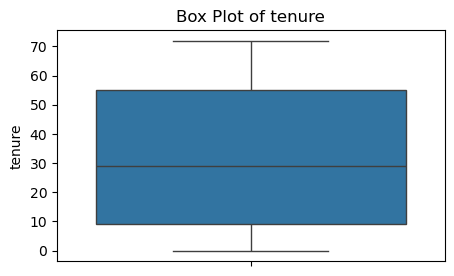

In [54]:
plot_boxplot(df, "tenure")

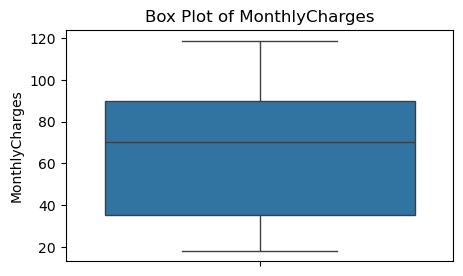

In [57]:
plot_boxplot(df, "MonthlyCharges")

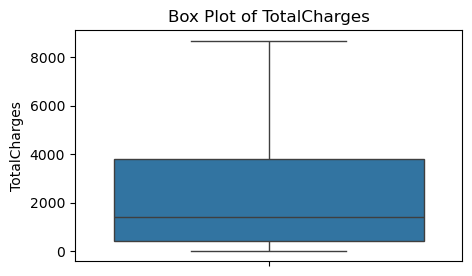

In [58]:
plot_boxplot(df, "TotalCharges")

Correlation Heatmap for numerical columns


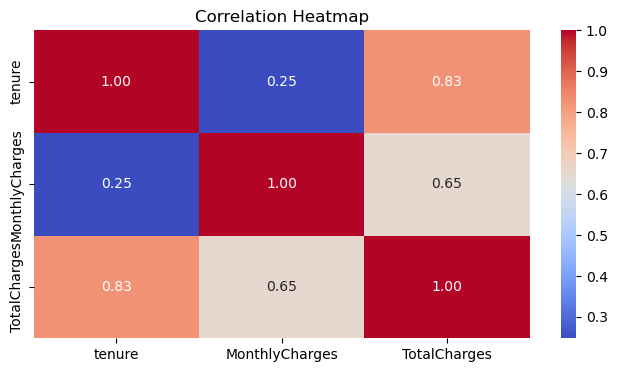

In [18]:
#correlation matrix - heatmap
plt.figure(figsize=(8,4))
sns.heatmap(df[["tenure", "MonthlyCharges",	"TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Categorical features -  Analysis

In [77]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


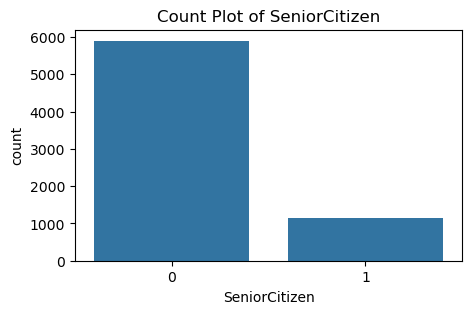

In [ ]:
object_cols = df.select_dtypes(include="object").columns.to_list()

object_cols = ["SeniorCitizen"] + object_cols

for col in object_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.show()

Data Preprocessing

In [20]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [ ]:
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0 })

In [ ]:
df.head(3)

In [16]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


Label Encoding of Categorical features

In [8]:
#identifying column with object data type
object_columns = df.select_dtypes(include="object").columns

In [30]:
print(object_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object')


In [78]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder   # this fixes the NameError
import pickle


In [6]:
from sklearn.preprocessing import LabelEncoder
import pickle

encoders = {}
categorical_columns = ["gender","Partner","Dependents","PhoneService","MultipleLines",
                       "InternetService","OnlineSecurity","OnlineBackup","DeviceProtection",
                       "TechSupport","StreamingTV","StreamingMovies","Contract",
                       "PaperlessBilling","PaymentMethod"]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Save encoders
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)


In [9]:
#initiate a dictionary to save the encoders
encoders = {}

#apply label encoding and store the encoders
for column in object_columns:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

#save the encoders with the pickle file
with open("encoders.pk1", "wb") as f:
    pickle.dump(encoders, f)

In [110]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'TotalCharges': LabelEncoder(),
 'Churn': LabelEncoder()}

In [33]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1


In [41]:
# 1. Clean column names
df.columns = df.columns.str.strip()

# 2. Drop customerID if present
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

# 3. Encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# 4. Define features and target
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

# 5. Split and balance
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [24]:
#spliting the features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [114]:
from sklearn.model_selection import train_test_split


In [25]:
#split taraining and test data
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [101]:
print(y_train.shape)

(5634,)


In [102]:
print(y_train .value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


Synthetic Minority Oversampling Technique(SMOTE)

In [27]:
smote = SMOTE(random_state=42)

In [28]:
X_train_smote,y_train_smote = smote.fit_resample(X_train, y_train)

In [103]:
print(y_train_smote.shape)

(8278,)


In [104]:
print(y_train_smote.value_counts())

Churn
0    4139
1    4139
Name: count, dtype: int64


Model training

In [3]:
!pip install xgboost

In [ ]:
%pip install xgboost


In [9]:
import sys
print(sys.executable)


C:\Users\kisho\Downloads\p\python.exe


In [ ]:
conda install -c conda-forge xgboost


In [29]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier   # Make sure xgboost is installed

# Dictionary of models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}


In [45]:
#Dictionary of models
model = {
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

    

In [61]:
for model_name, model in models.items():
    ...


In [91]:
#dictionary to store the cross validation results
cv_scores = {}

#perform 5-fold cross validation for each model
for model_name, model in models.items():
    print(f"training{model_name}with default parameters")
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
    cv_scores[model_name] = scores
    print(f"{model_name} cross validation accuracy : {np.mean(scores):.2f}")
    print("-"*70)


trainingDecision Treewith default parameters
Decision Tree cross validation accuracy : 0.78
----------------------------------------------------------------------
trainingRandom Forestwith default parameters
Random Forest cross validation accuracy : 0.84
----------------------------------------------------------------------
trainingXGBoostwith default parameters
XGBoost cross validation accuracy : 0.83
----------------------------------------------------------------------


In [122]:
cv_scores

{'Decision Tree': array([0.67391304, 0.71014493, 0.83152174, 0.82900302, 0.83746224]),
 'Random Forest': array([0.73067633, 0.76207729, 0.90942029, 0.89063444, 0.8858006 ]),
 'XGBoost': array([0.71195652, 0.75483092, 0.9160628 , 0.89607251, 0.89063444])}

Random forest gives the highest accuracy compared to other models with parameters

In [123]:
rfc = RandomForestClassifier(random_state=42)

In [127]:
rfc.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [125]:
print(y_test.value_counts())

Churn
0    1035
1     374
Name: count, dtype: int64


Model Evaluation

In [97]:
# Train the model on balanced training data
model.fit(X_train_smote, y_train_smote)

# Evaluate on test data
y_test_pred = model.predict(X_test)

# Print evaluation metrics
print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))


Accuracy Score:
 0.7771469127040455
Confusion Matrix:
 [[880 156]
 [158 215]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [128]:
#save the trained model as a pickle file
model_data = {"model": rfc, "features_names": X.columns.tolist()}

with open("rfc_model.pkl", "wb") as f:
    pickle.dump(rfc, f)

Load the saved model and build a preditictive system

In [137]:
# Suppose you already have cv_scores dictionary
import numpy as np

# Find the model with the best mean CV score
best_model_name = max(cv_scores, key=lambda k: np.mean(cv_scores[k]))
best_model = models[best_model_name]

# Train the best model on the full training set
best_model.fit(X_train_smote, y_train_smote)

print("Best model is:", best_model_name)


Best model is: Random Forest


In [138]:
import pickle

# Save the trained model and feature names
model_data = {
    "model": best_model,
    "features_names": X.columns.tolist()
}


with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Model saved successfully!")


Model saved successfully!


In [140]:
#load tech saved model and the feature names

with open("customer_churn_model.pkl", "rb") as f:
    model_data = pickle.load(f)

    loaded_model = model_data["model"]
    features_names = model_data["features_names"]

In [141]:
print(loaded_model)

RandomForestClassifier(random_state=42)


In [132]:
print(features_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [12]:
with open("customer_churn_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)


In [57]:
X = df.drop(columns=["Churn"])   # only drop target
y = df["Churn"]

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

import pickle
with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("feature_names.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)



In [59]:
# Prepare training data
X = df.drop(columns=["Churn"])   # only drop target
y = df["Churn"]

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Save model and feature names
import pickle
with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("feature_names.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)


In [61]:
import pandas as pd
import pickle

# Your input data
input_data = {
    "gender":"Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 1,
    "PhoneService": "No",
    "MultipleLines": "No phone service",
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 29.85,
    "TotalCharges": 29.85
}

input_data_df = pd.DataFrame([input_data])


with open("encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

for column, encoder in encoders.items():
    if column in input_data_df.columns:
        try:
            input_data_df[column] = encoder.transform(input_data_df[column])
        except ValueError:
            pass

# Load feature names
with open("feature_names.pkl", "rb") as f:
    feature_names = pickle.load(f)

# Align input columns to training order
input_data_df = input_data_df[feature_names]

# Load trained model
with open("customer_churn_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Make a prediction
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

#result
print(f"prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"prediction probability: {pred_prob}")


prediction: No Churn
prediction probability: [[0.67 0.33]]


In [117]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}